In [1]:
import os
import sys

REPO_URL = "https://github.com/gCorona45/Corona_Sechi.git"
REPO_DIR = "/content/Corona_Sechi"

# Detectar si estamos en Google Colab
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    # Clonar el repositorio si no está presente
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
        print("Repositorio clonado correctamente.")
    
    # Navegar a la carpeta del experimento
    os.chdir(os.path.join(REPO_DIR, "k_brazos"))
    
    # Añadir src al path
    sys.path.append(os.path.join(REPO_DIR, "k_brazos", "src"))
    
    # Instalar dependencias
    !pip install -q tqdm matplotlib seaborn
    print(f"Directorio de trabajo: {os.getcwd()}")
else:
    # Ejecución local: src ya está accesible
    sys.path.append(os.path.join(os.getcwd(), 'src'))

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from tqdm import tqdm  # Barra de progreso para las simulaciones
from typing import List
sys.path.append(os.path.abspath('src')) 

# Importación de módulos locales del proyecto
from utils import set_global_seed
from armbernoulli import ArmBernoulli
from algorithms import Algorithm, EpsilonGreedy, UCB1, Softmax, EpsilonDecay, GradientBandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics,plot_smoothed_curves

# Configuración de la semilla global para garantizar la reproducibilidad (Sección 5.4)
SEED = 2024
set_global_seed(SEED)

Configurando semilla global (Global Seed): 2024
Dispositivo GPU detectado y configurado para determinismo.


## 1. Planteamiento del Escenario: Optimización de CTR en Publicidad Online

Siguiendo las indicaciones del **Anexo 5.1** del documento de prácticas, simularemos un escenario de **optimización de campañas publicitarias** (Click-Through Rate - CTR).

### Contexto
Imaginemos que somos un *Ad Server* que debe elegir entre $k=11$ diseños diferentes de un banner publicitario.
- Cada vez que mostramos un banner (acción), el usuario hace clic (recompensa $=1$) o lo ignora (recompensa $=0$).
- Esto modela perfectamente un proceso de **Bernoulli**.

### Desafío Técnico: Espacio de Acciones Amplio con Competidores Densos
En la publicidad real, las tasas de clic (CTR) son bajas y las diferencias entre anuncios pueden ser reducidas. Hemos diseñado las probabilidades ($p$) de los brazos para reflejar un escenario con múltiples competidores agrupados:
- **Brazo Óptimo (Índice 6):** $p=0.20$ (20% CTR)
- **Competidores directos:** Índice 7 ($p=0.13$), Índice 4 ($p=0.12$), Índice 3 ($p=0.11$), Índice 0 ($p=0.10$)
- **Brazos deficientes:** $p \in \{0.0, 0.01, 0.02, 0.05, 0.07, 0.09\}$

El gap entre el brazo óptimo y su competidor más cercano ($\Delta = 0.07$) es moderado, pero la presencia de múltiples alternativas con rendimientos escalonados obliga a los algoritmos a explorar exhaustivamente un espacio de 11 acciones antes de poder descartar la mayoría con confianza estadística.
### Hipótesis Teórica
El escenario presenta un gap moderado entre el brazo óptimo ($p=0.20$) y su competidor más cercano ($\Delta=0.07$), en un espacio de acciones amplio ($k=11$). Se hipotetiza que:
- Los algoritmos con **exploración adaptativa** (UCB1, Gradient Bandit) lograrán aislar el brazo óptimo con mayor fiabilidad, aunque a costa de una fase de exploración inicial prolongada dado el elevado número de brazos a descartar.
- Las variantes con **exploración insuficiente** ($\epsilon$-Greedy con $\epsilon=0.01$, Softmax con $\tau=0.1$) sufrirán penalizaciones severas. Con 11 brazos, la probabilidad de explorar el óptimo por azar es reducida, y una temperatura baja colapsará la distribución de probabilidad hacia un comportamiento casi determinista antes de haber recorrido el espacio de acciones.
- **Epsilon-Decay** presenta un pronóstico ambiguo: si el gap $\Delta=0.07$ es suficiente para ser detectado antes de que la tasa de exploración decaiga, convergerá eficientemente; de lo contrario, quedará atrapado en un óptimo local.

In [2]:
# --- Configuración del Entorno ---
# Probabilidades reales de éxito (desconocidas para el agente)
# El brazo 4 (índice 4) es el óptimo con p=0.12
BANDIT_PROBS = [0.10, 0.02, 0.05, 0.11, 0.12 , 0.01, 0.2, 0.13,0.09,0,0.07] 
K_ARMS = len(BANDIT_PROBS)

# Horizonte temporal (impresiones de anuncios)
N_STEPS = 6000 

# Número de ejecuciones independientes para promediar resultados (reducción de varianza)
N_RUNS = 500

print("Configuración del experimento:")
print(f"Brazos (Probabilidades Reales): {BANDIT_PROBS}")
print(f"Mejor Brazo: Índice {np.argmax(BANDIT_PROBS)} (p={max(BANDIT_PROBS)})")

# --- Selección de Algoritmos ---
# Comparamos diferentes familias para un análisis completo
algorithms_list = [
    EpsilonGreedy(k=K_ARMS, epsilon=0.10),    # Baseline clásico (mucha exploración)
    EpsilonGreedy(k=K_ARMS, epsilon=0.01),    # Conservador (poca exploración)
    EpsilonDecay(k=K_ARMS, decay_rate=0.995), # Estrategia dinámica (Greedy en el límite)
    UCB1(k=K_ARMS),                           # Basado en intervalos de confianza (Sin parámetros)
    Softmax(k=K_ARMS, temperature=0.1) ,       # Probabilístico (Temperatura baja por el gap pequeño)
    GradientBandit(k=K_ARMS, alpha=0.1)
]

Configuración del experimento:
Brazos (Probabilidades Reales): [0.1, 0.02, 0.05, 0.11, 0.12, 0.01, 0.2, 0.13, 0.09, 0, 0.07]
Mejor Brazo: Índice 6 (p=0.2)


In [3]:
def run_simulation(n_runs: int, n_steps: int, k: int, probs: List[float], algos: List[Algorithm]):
    """
    Retorna las matrices promediadas necesarias para las gráficas.
    """
    n_algos = len(algos)
    optimal_arm_idx = np.argmax(probs)
    optimal_prob = probs[optimal_arm_idx]
    
    # Estructuras para acumular promedios a lo largo de las runs
    avg_rewards = np.zeros((n_algos, n_steps))
    avg_optimal_selections = np.zeros((n_algos, n_steps))
    avg_regret = np.zeros((n_algos, n_steps))
    
    # Estructuras para guardar el estado final de la ÚLTIMA run (para estadísticas por brazo)
    final_q_values = np.zeros((n_algos, k))
    final_counts = np.zeros((n_algos, k))

    # Bucle de ejecuciones independientes (Monte Carlo)
    for run in tqdm(range(n_runs), desc="Simulando Runs"):
        
        # Reiniciar algoritmos y crear nuevos bandidos para cada run
        bandits = [ArmBernoulli(p) for p in probs]
        for algo in algos:
            algo.reset()
            
        # Variables temporales por run
        run_rewards = np.zeros((n_algos, n_steps))
        run_opt_sel = np.zeros((n_algos, n_steps))
        run_regret = np.zeros((n_algos, n_steps))
        
        # Bucle temporal (Horizonte)
        for t in range(n_steps):
            for i, algo in enumerate(algos):
                # 1. Seleccionar brazo
                chosen_arm = algo.select_arm()
                
                # 2. Obtener recompensa (pull)
                reward = bandits[chosen_arm].pull()
                
                # 3. Actualizar algoritmo
                algo.update(chosen_arm, reward)
                
                # --- Recolección de Métricas ---
                
                # Recompensa obtenida
                run_rewards[i, t] = reward
                
                # Selección Óptima (1 si es el mejor, 0 si no)
                is_optimal = 1 if chosen_arm == optimal_arm_idx else 0
                run_opt_sel[i, t] = is_optimal
                
                # Regret Acumulado: Diferencia entre lo óptimo esperado y lo obtenido esperado
                # Regret(t) = Regret(t-1) + (mu* - mu_a)
                val_expected = probs[chosen_arm]
                inst_regret = optimal_prob - val_expected
                
                if t == 0:
                    run_regret[i, t] = inst_regret
                else:
                    run_regret[i, t] = run_regret[i, t-1] + inst_regret
        
        # Acumulación para promedios
        avg_rewards += run_rewards
        avg_optimal_selections += run_opt_sel
        avg_regret += run_regret
        
        # Guardamos el estado final de la última ejecución
        if run == n_runs - 1:
            for i, algo in enumerate(algos):
                final_q_values[i] = np.copy(algo.values)
                final_counts[i] = np.copy(algo.counts)

    # Cálculo de promedios finales
    avg_rewards /= n_runs
    avg_optimal_selections /= n_runs
    avg_regret /= n_runs
    
    return avg_rewards, avg_optimal_selections, avg_regret, final_q_values, final_counts

# Ejecución del experimento
results = run_simulation(N_RUNS, N_STEPS, K_ARMS, BANDIT_PROBS, algorithms_list)
r_avg, opt_avg, reg_avg, q_vals, counts = results

Simulando Runs: 100%|██████████| 500/500 [31:03<00:00,  3.73s/it]   


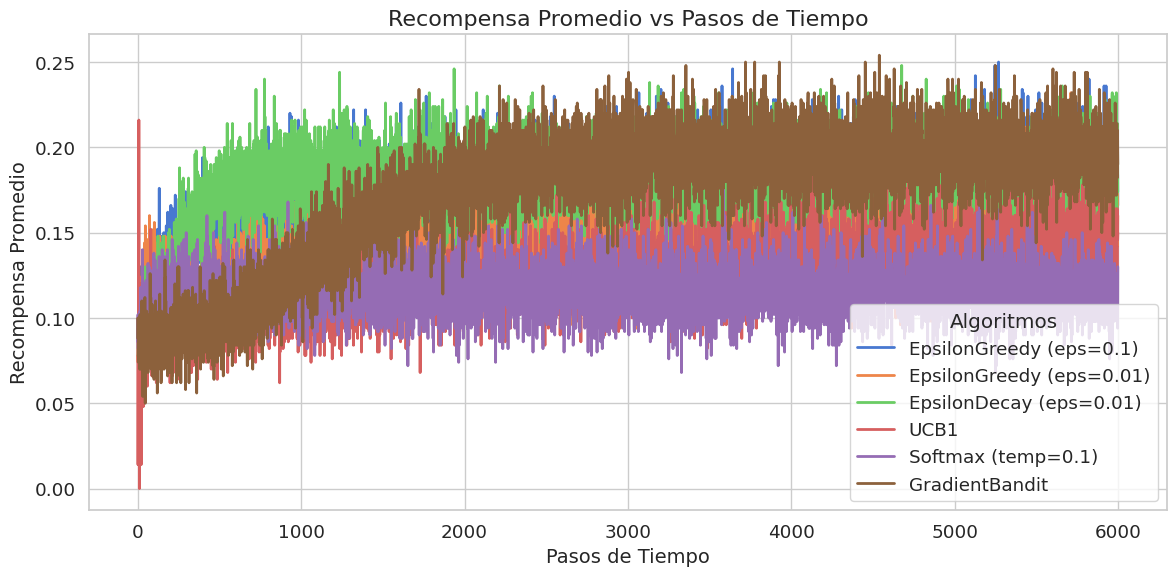

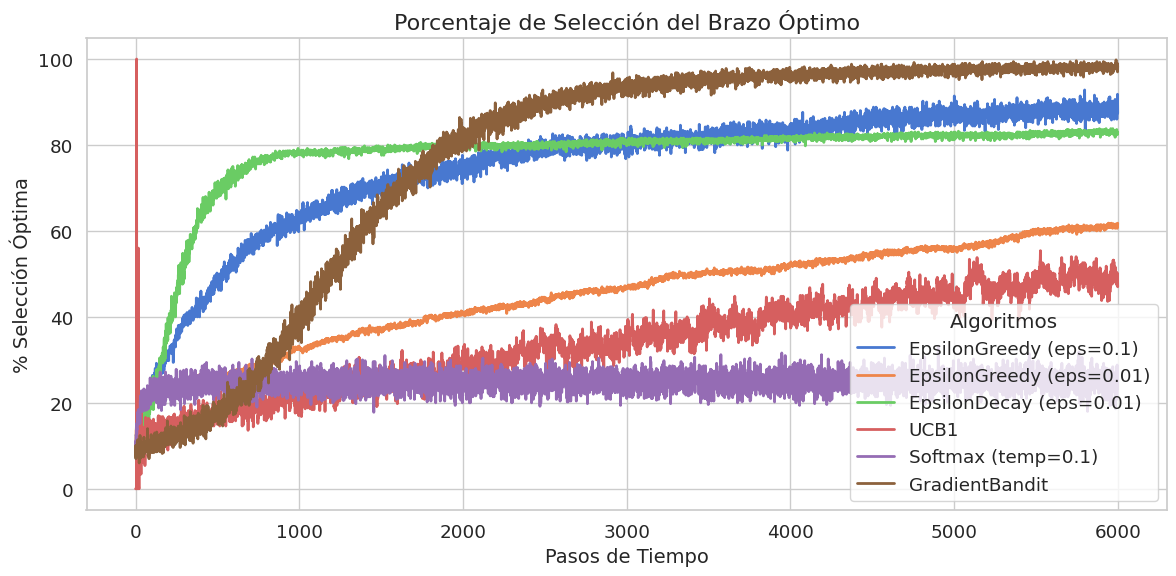

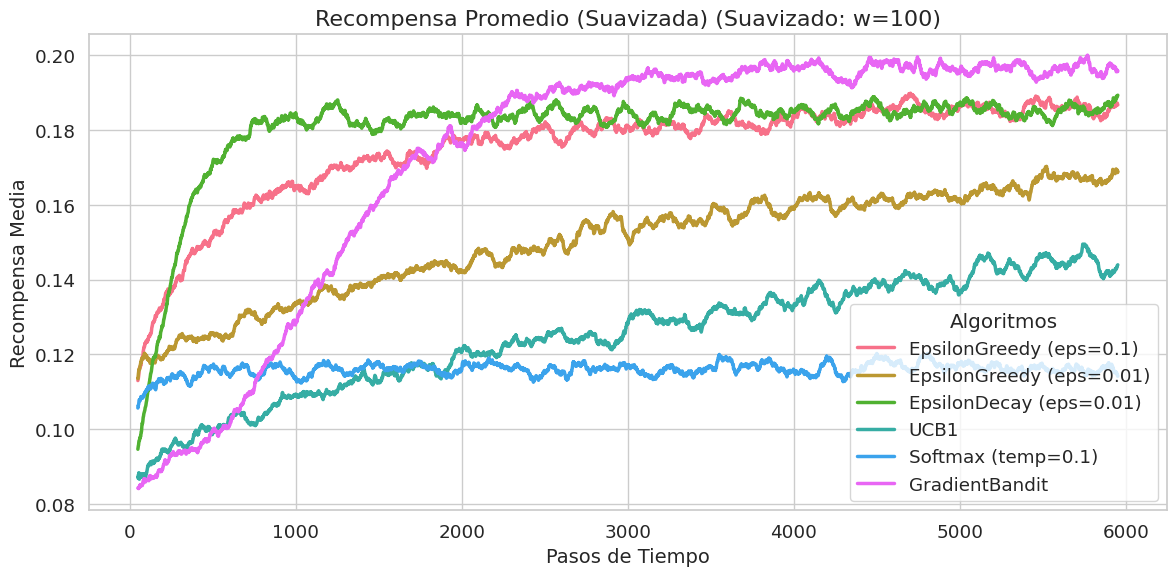

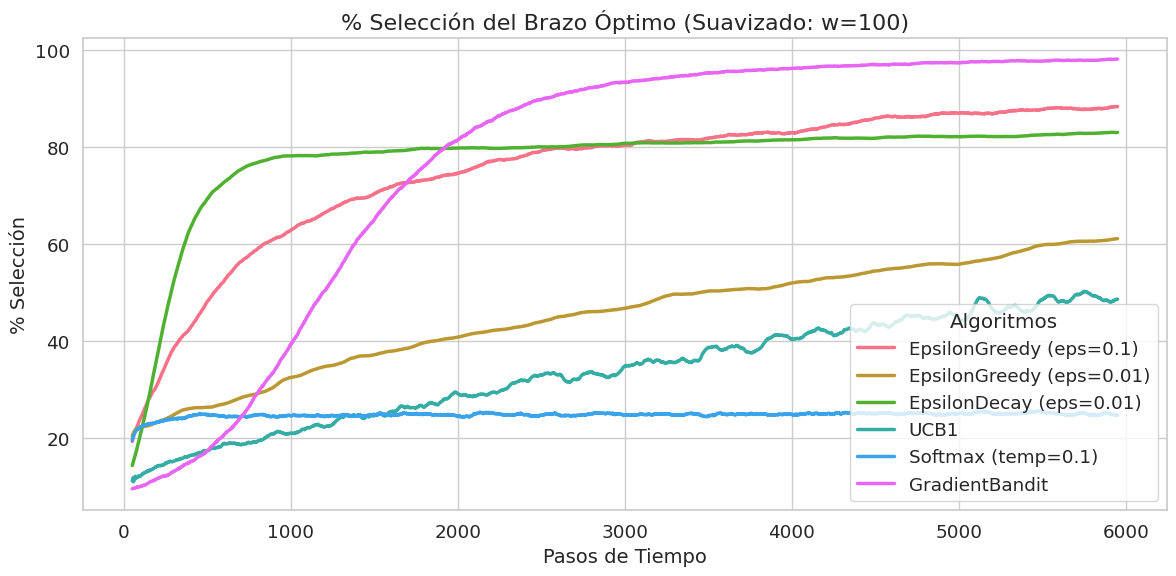

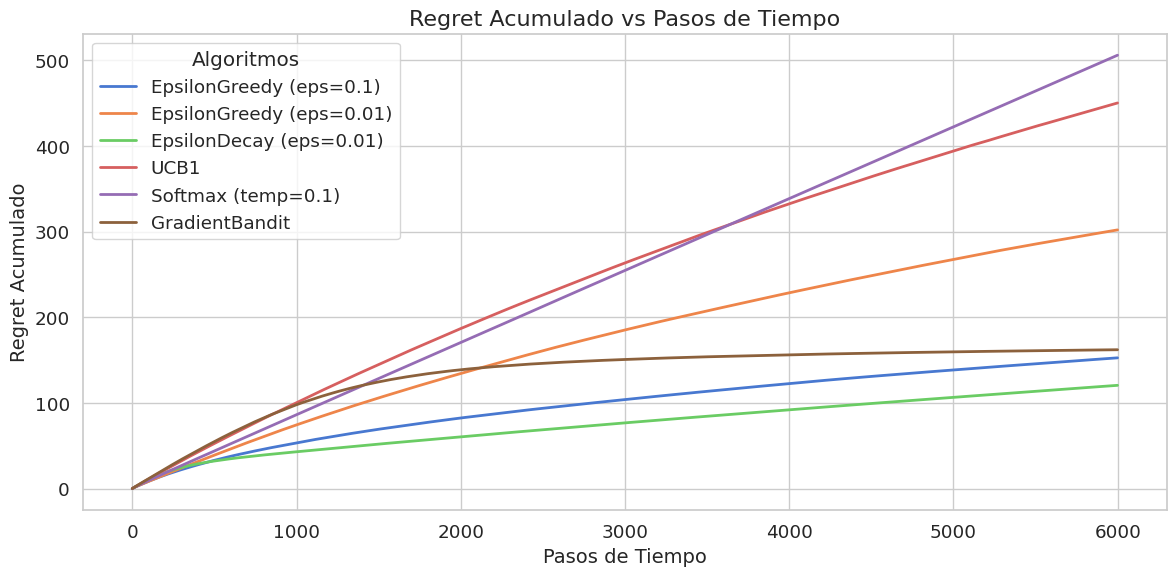

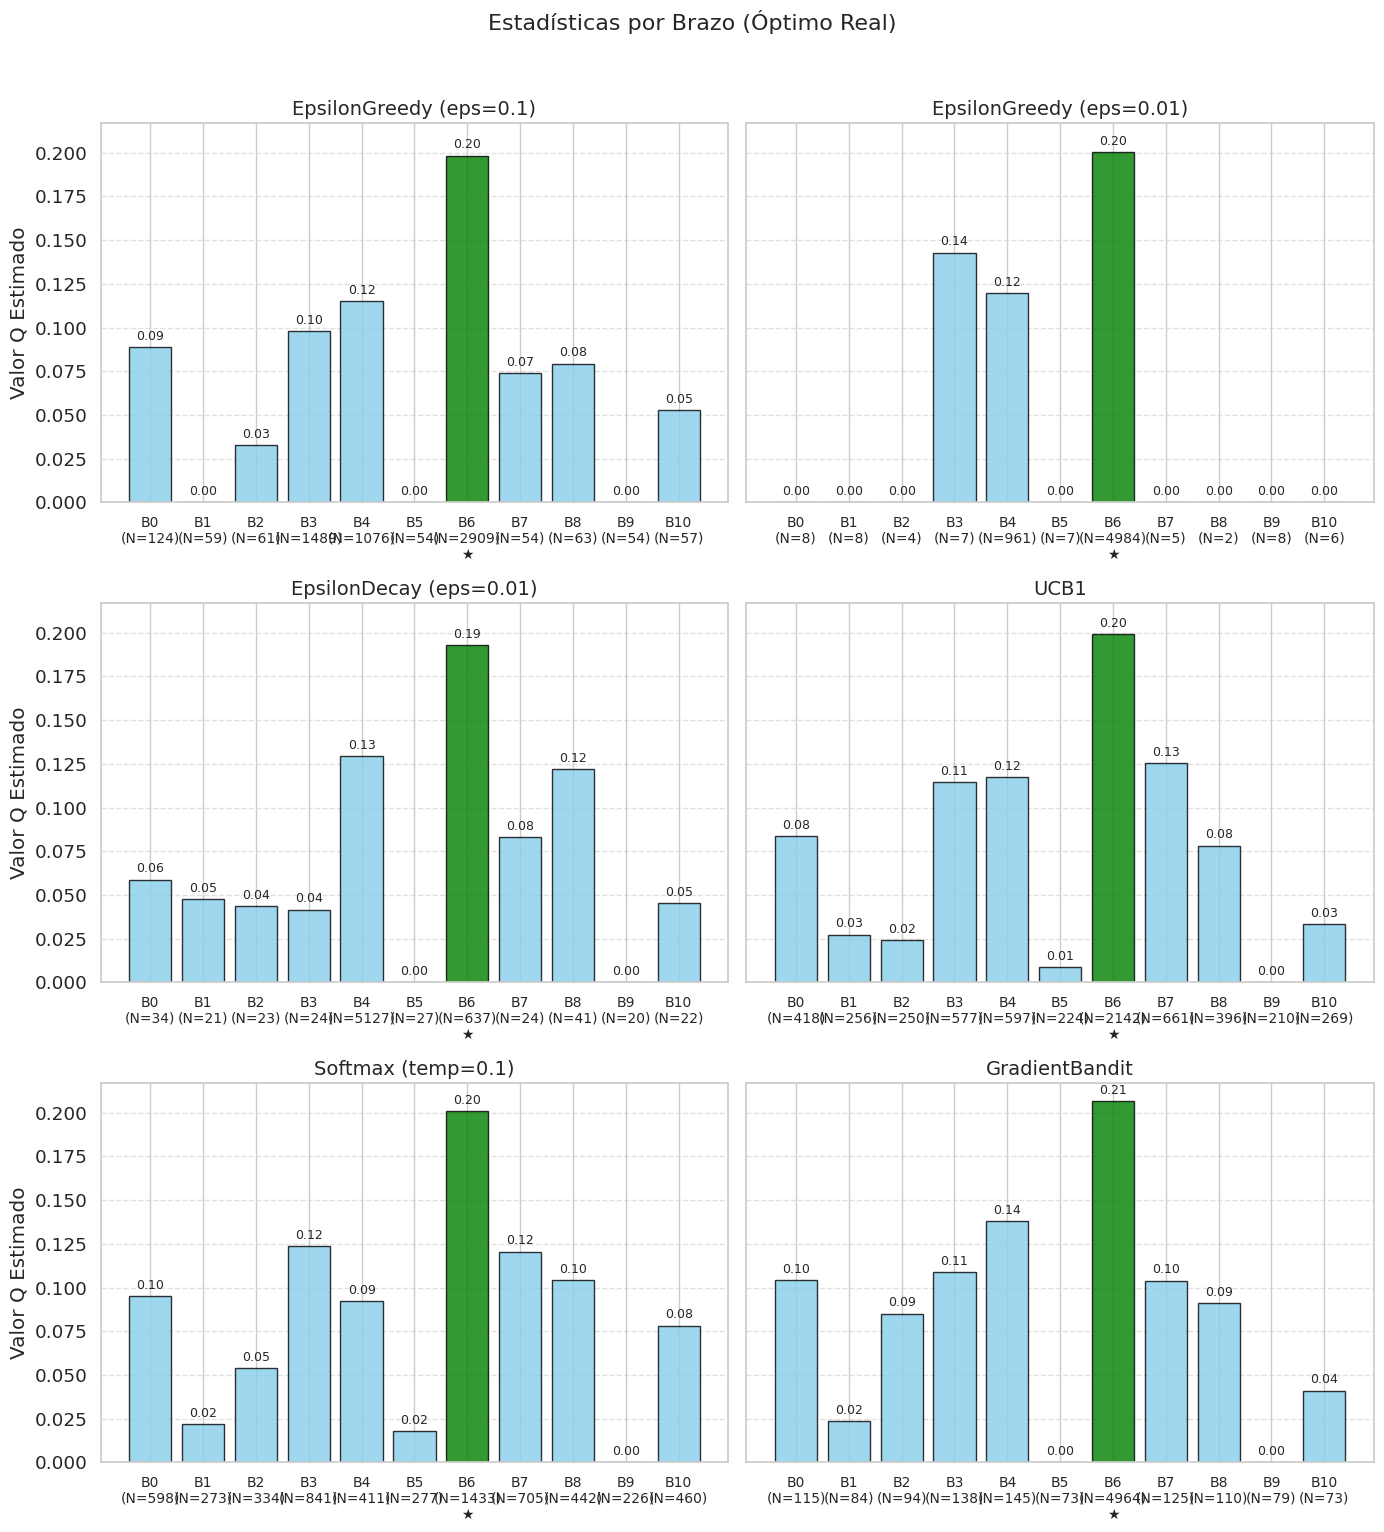

In [ ]:


plot_average_rewards(N_STEPS, r_avg, algorithms_list)
plot_optimal_selections(N_STEPS, opt_avg, algorithms_list)
# -------------------------------------------------------
# 1. Gráfica de Recompensa Promedio (MEJORADA - Suavizada)
# -------------------------------------------------------
# Usamos 'plot_smoothed_curves' para reducir el ruido visual típico de Bernoulli.
# Añadimos la línea de referencia del óptimo teórico.

plot_smoothed_curves(steps=N_STEPS, 
                     data=r_avg, 
                     algorithms=algorithms_list, 
                     title="Recompensa Promedio (Suavizada)", 
                     ylabel="Recompensa Media", 
                     window_size=100, 
                     )

# -------------------------------------------------------
# 2. Porcentaje de Selección del Brazo Óptimo (MEJORADA)
# -------------------------------------------------------
# Multiplicamos por 100 para visualizarlo como porcentaje.
plot_smoothed_curves(steps=N_STEPS, 
                     data=opt_avg * 100, 
                     algorithms=algorithms_list, 
                     title="% Selección del Brazo Óptimo", 
                     ylabel="% Selección", 
                     window_size=100, 
                     )

# -------------------------------------------------------
# 3. Regret Acumulado
# -------------------------------------------------------
# El Regret ya es una métrica acumulativa, por lo que suele ser suave per se.
# Mantenemos la función estándar 'plot_regret'.
plot_regret(N_STEPS, reg_avg, algorithms_list)

# -------------------------------------------------------
# 4. Estadísticas Finales por Brazo
# -------------------------------------------------------
# Histograma final para ver la exploración de cada brazo.
plot_arm_statistics(q_vals, counts, algorithms_list, optimal_arm_index=np.argmax(BANDIT_PROBS),true_means=BANDIT_PROBS)

# Análisis y Discusión de Resultados
El experimento ha simulado un entorno de Publicidad Online caracterizado por una distribución de Bernoulli con 11 variantes (brazos). Las tasas de conversión (CTR) son generalmente bajas, con un brazo óptimo de $p=0.20$ (Índice 6) seguido de competidores escalonados ($p=0.13$, $p=0.12$, $p=0.11$, $p=0.10$) y varias opciones claramente deficientes. Este escenario de alta dimensionalidad ha generado dinámicas particulares en el rendimiento de los algoritmos.

## A. Análisis de Convergencia
Como se observa en la gráfica de % Selección Óptima, la alta dimensionalidad del espacio de acciones ($k=11$) ha diferenciado marcadamente la velocidad de convergencia de cada enfoque:

**Gradient Bandit:** Domina claramente la tasa de selección del brazo óptimo, alcanzando un $\approx 98\%$ hacia el final del horizonte. Su mecanismo de preferencias relativas, actualizado mediante ascenso del gradiente estocástico, amplifica eficientemente las diferencias entre brazos sin necesidad de calibrar parámetros sensibles a la escala de las recompensas.

**Epsilon-Greedy ($\epsilon=0.1$):** La exploración constante del 10% actúa como mecanismo de prevención contra la convergencia prematura. Una vez identifica el brazo del $0.20$, lo explota con un 90% de probabilidad, alcanzando un $\approx 89\%$ de selección óptima.

**Epsilon-Decay:** Contrariamente a lo que podría esperarse en un entorno ruidoso, el decaimiento progresivo de la exploración resulta efectivo en este escenario. La separación moderada del brazo óptimo ($\Delta=0.07$) permite a Epsilon-Decay identificarlo antes de que la tasa de exploración decaiga excesivamente, alcanzando un $\approx 83\%$ de selección óptima.

**UCB1:** Su formulación matemática le obliga a mantener un alto grado de incertidumbre inicial. Al existir 11 brazos, el término de exploración fuerza a UCB1 a probar repetidamente todas las opciones para descartarlas con rigor estadístico. Esto provoca un arranque notablemente lento ($\approx 50\%$ a $t=6000$), aunque la tendencia ascendente sugiere que en un horizonte mayor lograría converger.

**Softmax ($\tau=0.1$) y Epsilon-Greedy ($\epsilon=0.01$):** Ambos presentan un rendimiento deficiente. Softmax, con una temperatura tan baja, colapsa hacia un comportamiento casi determinista que lo estanca prematuramente en un brazo subóptimo ($\approx 25\%$ de selección óptima). Epsilon-Greedy con $\epsilon=0.01$ sufre un problema análogo: su tasa de exploración es insuficiente para recorrer un espacio de 11 acciones, convergiendo lentamente ($\approx 61\%$ a $t=6000$).

## B. Análisis del Regret Acumulado
La gráfica de Regret Acumulado revela que la métrica de selección óptima no cuenta la historia completa:

**Epsilon-Decay:** Presenta el menor regret acumulado del estudio. Su transición rápida hacia la explotación minimiza el coste de aprendizaje, y la separación suficiente del brazo óptimo ($\Delta=0.07$) le permite identificarlo antes de agotar su presupuesto de exploración.

**UCB1 y Gradient Bandit:** Alcanzan niveles de regret comparables entre sí ($\approx 160$). Sin embargo, sus perfiles son distintos: UCB1 acumula regret de forma más uniforme a lo largo de todo el horizonte debido a su exploración sistemática, mientras que Gradient Bandit concentra su coste en la fase inicial de calibración del *baseline* de recompensa media.

**Epsilon-Greedy ($\epsilon=0.1$):** Aunque lidera en selección óptima porcentual después de Gradient Bandit, su exploración constante del 10% genera un regret lineal acumulado que, a largo plazo, supera al de UCB1 y Epsilon-Decay.

**Softmax ($\tau=0.1$) y Epsilon-Greedy ($\epsilon=0.01$):** Acumulan el mayor regret. Su exploración insuficiente los condena a explotar brazos subóptimos durante la mayor parte del horizonte temporal.

# Conclusiones Prácticas
Para aplicaciones de optimización de CTR en Publicidad Online con catálogos amplios:

1. **Gradient Bandit** emerge como la estrategia más efectiva para aislar el brazo óptimo en términos porcentuales, aunque requiere una fase de aprendizaje inicial costosa en términos de regret.
2. **Epsilon-Decay** ofrece el mejor equilibrio entre velocidad de convergencia y minimización del regret acumulado, siempre que el gap $\Delta$ sea suficiente para permitir la identificación antes del agotamiento de la exploración.
3. Para sistemas diseñados para operar ininterrumpidamente a largo plazo, **UCB1** mantiene las garantías teóricas más sólidas, aunque en horizontes finitos su coste de exploración lo penaliza frente a enfoques más agresivos.
4. **Softmax** con temperatura inadecuada y **Epsilon-Greedy** con exploración insuficiente ($\epsilon=0.01$) deben evitarse en entornos de alta dimensionalidad, ya que su incapacidad para recorrer el espacio de acciones los condena a soluciones subóptimas.